# 02c Construcción formal de la red

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Define el grafo que se usa en el análisis (sección 3.2 del artículo): qué es un nodo y una arista, si es dirigido, cómo se ponderan las aristas y cómo se vinculan los POI. Trabaja sin red, sobre el grafo limpio (`01`) y los POI integrados (`02b`).

Incluye una **isócrona de prueba** desde un hospital, que valida los pesos y sirve de adelanto del Hito 2.

## 1. Carga

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg
from src import red

np.random.seed(cfg.SEED)

G = ox.load_graphml(cfg.DATA_INTERIM / "walk_graph_clean.graphml")
limites_utm = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)
poi = pd.read_csv(cfg.DATA_PROCESSED / "poi_snap.csv")
poi = poi[poi["snap_valido"]].copy()
print(f"Grafo limpio: {type(G).__name__}, {G.number_of_nodes():,} nodos, {G.number_of_edges():,} aristas, CRS {G.graph['crs']}")
print(f"POI válidos: {len(poi)} -> {poi['capa'].value_counts().to_dict()}")

Grafo limpio: MultiDiGraph, 17,265 nodos, 51,216 aristas, CRS EPSG:32718
POI válidos: 583 -> {'educacion': 407, 'mercados': 102, 'salud': 74}


## 2. Definición formal

- **Nodo** *v ∈ V*: intersección o final de vía peatonal (calle, vereda, pasaje, escalera) de OpenStreetMap, con coordenadas (*x*, *y*) en EPSG:32718 y la etiqueta `distrito` (`Miraflores`, `San Juan de Miraflores` o `Fuera (buffer)`).
- **Arista** *e = (u, v) ∈ E*: segmento transitable entre dos nodos, con longitud `length` (m) y geometría.
- **Grafo** *G = (V, E, w)*, espacial y ponderado, con peso *w(e)* = tiempo de caminata.

Se comprueba que no quedan bucles ni aristas paralelas (la limpieza los eliminó), condición para tratarlo como grafo simple.

In [2]:
n_bucles = nx.number_of_selfloops(G)
n_paralelas = sum(len(G[u][v]) > 1 for u, v in G.edges())
print(f"Bucles: {n_bucles} | pares (u, v) con aristas paralelas: {n_paralelas}")
assert n_bucles == 0 and n_paralelas == 0

Bucles: 0 | pares (u, v) con aristas paralelas: 0


## 3. ¿Dirigido o no dirigido?

En `walk` osmnx ignora `oneway`: toda calle se puede recorrer en ambos sentidos. Se verifica en los datos que el grafo es **simétrico**: cada arista (u, v) tiene su inversa (v, u) con la misma longitud.

In [3]:
pares = {(u, v): d["length"] for u, v, d in G.edges(data=True)}
con_inversa = [(u, v) for (u, v) in pares if (v, u) in pares]
dif = [abs(pares[(u, v)] - pares[(v, u)]) for (u, v) in con_inversa]
print(f"Aristas dirigidas: {len(pares):,} | con inversa: {len(con_inversa):,} ({len(con_inversa)/len(pares):.2%})")
print(f"Diferencia máxima de longitud entre (u,v) y (v,u): {max(dif):.3f} m")
sin_inversa = [(u, v) for (u, v) in pares if (v, u) not in pares]
print(f"Aristas sin inversa: {len(sin_inversa)}")

Aristas dirigidas: 51,216 | con inversa: 51,216 (100.00%)
Diferencia máxima de longitud entre (u,v) y (v,u): 0.000 m
Aristas sin inversa: 0


**Decisión:** se trabaja con un **grafo dirigido simple** (`DiGraph`), compatible con osmnx y con los algoritmos de camino mínimo, y se usa una vista **no dirigida** donde la teoría lo pide (agrupamiento, componentes). Al ser simétrico, ambas dan los mismos tiempos de viaje.

## 4. Ponderación

- **Peso principal:** `tiempo_min` = longitud (m) / velocidad de caminata. Velocidad constante de `WALK_SPEED_KMH` = 4.8 km/h = 80 m/min.
- Justificación: OSM no trae velocidad peatonal; 4.8 km/h es una velocidad habitual de caminata adulta. Límite conocido: no considera pendiente, cruces ni escaleras (en SJM hay laderas; la penalización por escaleras es una extensión posible para el Hito 2).
- Equivalencias: 5 min = 400 m, 10 min = 800 m, 15 min = 1 200 m.

In [4]:
D = red.construir_digrafo(G, cfg.WALK_SPEED_KMH)
mpm = red.metros_por_minuto(cfg.WALK_SPEED_KMH)
print(f"Velocidad: {cfg.WALK_SPEED_KMH} km/h = {mpm:.0f} m/min")
print("Distancia equivalente:", {f"{m} min": f"{m * mpm:,.0f} m" for m in cfg.ISOCHRONE_MINUTES})
print(f"DiGraph: {D.number_of_nodes():,} nodos, {D.number_of_edges():,} aristas dirigidas")

aristas = pd.DataFrame([d for _, _, d in D.edges(data=True)])
aristas[["length", "tiempo_min"]].describe().round(3)

Velocidad: 4.8 km/h = 80 m/min
Distancia equivalente: {'5 min': '400 m', '10 min': '800 m', '15 min': '1,200 m'}
DiGraph: 17,265 nodos, 51,216 aristas dirigidas


,length,tiempo_min
count,51216.000,51216.000
mean,46.579,0.582
std,43.920,0.549
min,0.109,0.001
25%,15.166,0.190
50%,37.608,0.470
75%,59.933,0.749
max,737.657,9.221


In [5]:
# Vista no dirigida (grafo simple): cada par simétrico cuenta una vez
Gu = D.to_undirected()
print(f"Vista no dirigida: {Gu.number_of_nodes():,} nodos, {Gu.number_of_edges():,} aristas | componentes: {nx.number_connected_components(Gu)}")

Vista no dirigida: 17,265 nodos, 25,608 aristas | componentes: 2


## 5. Integración de los POI

Cada POI válido (`02b`) está asignado a su nodo más cercano. Se anotan en cada nodo cuántos POI de cada capa tiene asociados (`n_salud`, `n_educacion`, `n_mercados`). Estos nodos son los **orígenes** de las isócronas.

In [6]:
for capa in ["salud", "educacion", "mercados"]:
    conteo = poi.loc[poi["capa"] == capa, "nodo_osmid"].value_counts().to_dict()
    nx.set_node_attributes(D, {n: conteo.get(n, 0) for n in D.nodes}, f"n_{capa}")

nodos_df = pd.DataFrame.from_dict(dict(D.nodes(data=True)), orient="index")
tabla = pd.DataFrame({
    "POI": [(nodos_df[f"n_{c}"]).sum() for c in ("salud", "educacion", "mercados")],
    "nodos con POI": [(nodos_df[f"n_{c}"] > 0).sum() for c in ("salud", "educacion", "mercados")],
}, index=["salud", "educacion", "mercados"])
tabla

,POI,nodos con POI
salud,74,70
educacion,407,364
mercados,102,100


## 6. Isócrona de prueba

Se toma un hospital de Miraflores y se calculan los nodos alcanzables en 5, 10 y 15 min con Dijkstra ponderado por `tiempo_min`. **Validación:** el resultado debe coincidir con el obtenido usando directamente la longitud con corte 400, 800 y 1 200 m. (Como el grafo es simétrico, los nodos desde los que se llega al hospital son los mismos que se alcanzan desde él.)

In [7]:
h = poi[(poi["capa"] == "salud") & (poi["categoria"] == "hospital") & (poi["zona"] == "Miraflores")].sort_values("name").iloc[0]
origen = int(h["nodo_osmid"])
print(f"Hospital de prueba: {h['name']} | nodo {origen} | snap {h['dist_snap_m']:.1f} m")

t = nx.single_source_dijkstra_path_length(D, origen, cutoff=max(cfg.ISOCHRONE_MINUTES), weight="tiempo_min")
d = nx.single_source_dijkstra_path_length(D, origen, cutoff=max(cfg.ISOCHRONE_MINUTES) * mpm, weight="length")

filas = []
for m in cfg.ISOCHRONE_MINUTES:
    por_tiempo = {n for n, v in t.items() if v <= m}
    por_longitud = {n for n, v in d.items() if v <= m * mpm}
    assert por_tiempo == por_longitud, f"Difieren a {m} min"
    filas.append({"minutos": m, "metros": round(m * mpm), "nodos alcanzados": len(por_tiempo),
                  "% de nodos del grafo": round(len(por_tiempo) / D.number_of_nodes() * 100, 1)})
print("Validación tiempo vs. longitud: OK")
pd.DataFrame(filas)

Hospital de prueba: Hospital Central FAP | nodo 11108799121 | snap 39.8 m
Validación tiempo vs. longitud: OK


,minutos,metros,nodos alcanzados,% de nodos del grafo
0,5,400,105,0.6
1,10,800,272,1.6
2,15,1200,634,3.7


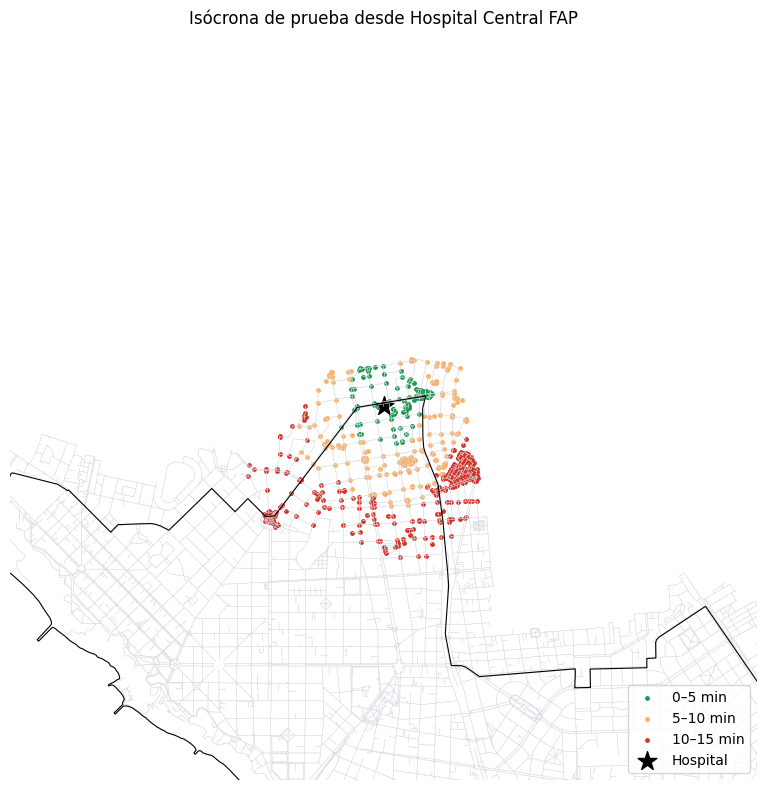

In [8]:
nodos = ox.graph_to_gdfs(G, edges=False)
aristas_gdf = ox.graph_to_gdfs(G, nodes=False)
alc = nodos.loc[list(t)].copy()
alc["minutos"] = pd.Series(t)
alc["banda"] = pd.cut(alc["minutos"], [-0.01, 5, 10, 15], labels=["0–5 min", "5–10 min", "10–15 min"])
colores = {"0–5 min": "#1a9850", "5–10 min": "#fdae61", "10–15 min": "#d73027"}

fig, ax = plt.subplots(figsize=(8, 8))
aristas_gdf.plot(ax=ax, color="#d9dce1", linewidth=0.3)
limites_utm.boundary.plot(ax=ax, color="k", lw=0.8)
for banda, color in colores.items():
    alc[alc["banda"] == banda].plot(ax=ax, color=color, markersize=6, label=banda)
nodos.loc[[origen]].plot(ax=ax, color="k", marker="*", markersize=200, label="Hospital")
x0, y0 = nodos.loc[origen].geometry.x, nodos.loc[origen].geometry.y
ax.set_xlim(x0 - 2500, x0 + 2500)
ax.set_ylim(y0 - 2500, y0 + 2500)
ax.legend(loc="lower right")
ax.set_title(f"Isócrona de prueba desde {h['name']}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [9]:
# Nodos alcanzados por distrito (el hospital está en Miraflores)
pd.crosstab(alc["banda"], alc["distrito"])

distrito,Fuera (buffer),Miraflores
banda,,
0–5 min,61,44
5–10 min,88,79
10–15 min,253,109


### Hallazgos

- **Grafo simple y simétrico:** sin bucles ni aristas paralelas; el 100 % de las aristas tiene inversa con la misma longitud (diferencia máxima 0.000 m). El `DiGraph` tiene 17 265 nodos y 51 216 aristas dirigidas; la vista no dirigida, 25 608 aristas y 2 componentes (uno por distrito).
- **Ponderación:** velocidad constante de 4.8 km/h (80 m/min); 5, 10 y 15 min equivalen a 400, 800 y 1 200 m. La arista media mide 46.6 m (0.58 min); la mayor, 737.7 m (9.2 min).
- **POI como orígenes:** 583 POI válidos en 527 nodos distintos (por capa: 70 de salud, 364 de educación y 100 de mercados); varios POI comparten nodo.
- **Isócrona de prueba (Hospital Central FAP):** alcanza 105 nodos en 5 min, 272 en 10 min y 634 en 15 min (3.7 % del grafo). Coincide exactamente con el cálculo por longitud, lo que valida los pesos.
- **Efecto de borde visible:** de los 362 nodos alcanzados entre 10 y 15 min, 253 (70 %) caen en el buffer, fuera de Miraflores; entre 5 y 10 min son 88 de 167 (53 %). Gran parte de la isócrona sale del distrito, por lo que el tratamiento del borde (`docs/hito2/01_nota_ampliar_grafo.md`) afecta a los resultados.